### 구글 드라이브 마운트

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 라이브러리 import

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm.notebook import tqdm
import copy
import random
from torch.utils.data import Subset

### 데이터셋 로드

In [ ]:
pgv_path = "#"
seismic_path = "#"
gnss_path = "#"

In [4]:
class Dataset(Dataset):
    def __init__(self, pgv_path, seismic_path, gnss_path, is_train=True):
        # 지진파형 로드
        seismic_data = np.load(seismic_path, allow_pickle=True)
        self.seismic = seismic_data['data']
        self.seismic_station = seismic_data['station_names']

        # gnss 로드
        gnss_data = np.load(gnss_path, allow_pickle=True)
        self.gnss = gnss_data['data']
        self.gnss_station = gnss_data['station_names']

        # pgv 라벨 로드
        pgv_data = pd.read_csv(pgv_path)
        self.pgv_dict = dict(zip(
            pgv_data['seismic_station'].astype(str).str.strip(),
            pgv_data['pgv']
        ))
        self.is_train = is_train

    def __len__(self):
        return len(self.seismic)

    def __getitem__(self, idx):
        seismic = np.copy(self.seismic[idx])
        gnss = np.copy(self.gnss[idx])

        seismic = np.squeeze(seismic, axis=0)
        gnss = np.squeeze(gnss, axis=0)

        seismic_station = str(self.seismic_station[idx]).strip().strip("[]'\"")
        gnss_station = str(self.gnss_station[idx]).strip().strip("[]'\"")

        # 로그 스케일링
        raw_pgv = self.pgv_dict.get(seismic_station, 0.0)
        pgv_label = np.log1p(raw_pgv)

        # Data Augmentation
        if self.is_train:
            # Scale Amplitude
            if random.random() < 0.3:
                scale_factor = random.uniform(0.5, 2.0)
                seismic *= scale_factor
                gnss *= scale_factor

            # Drop Channel
            if random.random() < 0.2:
                c1, c2, c3 = random.choice([0, 1]), random.choice([0, 1]), random.choice([0, 1])
                if c1 + c2 + c3 > 0:
                    if c1 == 0:
                      seismic[:, :, 0] = 0
                      gnss[:, :, 0] = 0
                    if c2 == 0:
                      seismic[:, :, 1] = 0
                      gnss[:, :, 1] = 0
                    if c3 == 0:
                      seismic[:, :, 2] = 0
                      gnss[:, :, 2] = 0

            # Add Gaussian Noise
            if random.random() < 0.3:
                for w in range(8):
                    for ch in range(3):
                        s_noise_amp = random.uniform(0.01, 0.15) * np.max(np.abs(seismic[w, :, ch]) + 1e-8)
                        seismic[w, :, ch] += np.random.normal(0, s_noise_amp, seismic.shape[1])
                        g_noise_amp = random.uniform(0.01, 0.15) * np.max(np.abs(gnss[w, :, ch]) + 1e-8)
                        seismic[w, :, ch] += np.random.normal(0, g_noise_amp, gnss.shape[1])

        seismic = np.transpose(seismic, (0, 2, 1))
        gnss = np.transpose(gnss, (0, 2, 1))

        # 정규화
        # 지진파형
        seismic = seismic.astype(np.float32)
        s_mean = np.mean(seismic, axis=-1, keepdims=True)
        s_std = np.std(seismic, axis=-1, keepdims=True)
        seismic = (seismic - s_mean) / (s_std + 1e-8)

        # GNSS
        gnss = gnss.astype(np.float32)
        g_mean = np.mean(gnss, axis=-1, keepdims=True)
        g_std = np.std(gnss, axis=-1, keepdims=True)
        gnss = (gnss - g_mean) / (g_std + 1e-8)

        x_seismic_tensor = torch.tensor(seismic, dtype=torch.float32)
        x_gnss_tensor = torch.tensor(gnss, dtype=torch.float32)
        y_tensor = torch.tensor([pgv_label], dtype=torch.float32)

        return x_seismic_tensor, x_gnss_tensor, y_tensor

### Seismic Encoder

In [5]:
class ResNetBlock(nn.Module):
    def __init__(self, filters, kernel_size, drop_rate):
        super(ResNetBlock, self).__init__()
        padding = kernel_size // 2

        self.bn1 = nn.BatchNorm1d(filters)
        self.drop1 = nn.Dropout1d(drop_rate)
        self.conv1 = nn.Conv1d(filters, filters, kernel_size, padding=padding)

        self.bn2 = nn.BatchNorm1d(filters)
        self.drop2 = nn.Dropout1d(drop_rate)
        self.conv2 = nn.Conv1d(filters, filters, kernel_size, padding=padding)

    def forward(self, x):
        res = x
        # 첫 번째 레이어
        out = self.bn1(x)
        out = F.relu(out)
        out = self.drop1(out)
        out = self.conv1(out)
        # 두 번째 레이어
        out = self.bn2(out)
        out = F.relu(out)
        out = self.drop2(out)
        out = self.conv2(out)
        # 잔차 연결 (Add)
        return out + res


class BiLSTMBlock(nn.Module):
    def __init__(self, in_channels, filters, drop_rate):
        super(BiLSTMBlock, self).__init__()
        self.drop_rate = drop_rate
        self.bilstm = nn.LSTM(input_size=in_channels, hidden_size=filters,
                              num_layers=1, batch_first=True, bidirectional=True)
        self.nin = nn.Conv1d(filters * 2, filters, kernel_size=1)
        self.bn = nn.BatchNorm1d(filters)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = F.dropout(x, p=self.drop_rate, training=self.training)

        out, _ = self.bilstm(x)

        out = out.permute(0, 2, 1)
        out = self.nin(out)
        out = self.bn(out)
        return out


class SeismicEncoder(nn.Module):
    def __init__(self, drop_rate=0.1, output_dim=128):
        super(SeismicEncoder, self).__init__()

        filters = [8, 16, 16, 32, 32, 96, 96]
        kernels = [11, 9, 7, 7, 5, 5, 3]

        # Conv
        self.encoder_convs = nn.ModuleList()
        in_c = 3
        for out_c, k in zip(filters, kernels):
            self.encoder_convs.append(nn.Sequential(
                nn.Conv1d(in_c, out_c, kernel_size=k, padding=k//2),
                nn.ReLU(),
                nn.MaxPool1d(2)
            ))
            in_c = out_c

        # ResCNN
        self.resnet_blocks = nn.ModuleList()
        for cb in range(5):
            self.resnet_blocks.append(ResNetBlock(96, kernel_size=3, drop_rate=drop_rate))
            if cb > 2:
                self.resnet_blocks.append(ResNetBlock(96, kernel_size=3, drop_rate=drop_rate))

        # Bi-LSTM / NiN
        self.bilstm_blocks = nn.ModuleList()
        lstm_in_c = 96
        for _ in range(3):
            self.bilstm_blocks.append(BiLSTMBlock(in_channels=lstm_in_c, filters=16, drop_rate=drop_rate))
            lstm_in_c = 16

        # Transformer
        encoder_layer = nn.TransformerEncoderLayer(d_model=16, nhead=2, dim_feedforward=128,
                                                   dropout=drop_rate, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # 특징맵 차원 조정
        self.final_projection = nn.Linear(16, output_dim)

    def forward(self, x):
        for conv in self.encoder_convs:
            x = conv(x)
        for resnet in self.resnet_blocks:
            x = resnet(x)
        for bilstm in self.bilstm_blocks:
            x = bilstm(x)
        x = x.permute(0, 2, 1)
        x = self.transformer(x)

        feature_map = self.final_projection(x)

        return feature_map

### GNSS Encoder

In [6]:
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, k=7, dropout=0.0):
        super().__init__()
        pad = k // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, k, padding=pad, bias=False)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, k, padding=pad, bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.drop = nn.Dropout(dropout) if dropout and dropout > 0 else nn.Identity()

        self.proj = None
        if in_ch != out_ch:
            self.proj = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, bias=False),
                nn.BatchNorm1d(out_ch),
            )

    def forward(self, x):
        shortcut = x
        x = self.drop(F.relu(self.bn1(self.conv1(x))))
        x = self.bn2(self.conv2(x))
        if self.proj is not None:
            shortcut = self.proj(shortcut)
        return F.relu(x + shortcut)

class TransformerBlock(nn.Module):
    """Attn + FFN with residual connections."""
    def __init__(self, d_model, num_heads=2, dropout=0.1, ff_mult=2):
        super().__init__()
        self.mha = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.ln1 = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * ff_mult),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * ff_mult, d_model),
        )
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x, return_attn=False):
        attn_out, attn_w = self.mha(x, x, x, need_weights=return_attn)
        x = self.ln1(x + attn_out)

        ff = self.ffn(x)
        x = self.ln2(x + ff)

        if return_attn:
            return x, attn_w
        return x

class GNSSEncoder(nn.Module):
    """
    Window-level GNSS encoder

    Input : (B, T, 3)
    Output: (B, T', F)

    B = batch of windows
    T = time length per window
    F = feature dimension (= 2 * lstm_units)
    """
    def __init__(
            self,
            in_ch=3,
            base_filters=32,
            res_depth=2,
            lstm_units=64,
            num_heads=2,
            dropout=0.15,
            k=7,
            ff_mult=2,
            downsample="none",      # "none" | "pool" | "conv"
            auto_downsample=False,
            threshold_T=512,
    ):
        super().__init__()
        self.auto_downsample = auto_downsample
        self.threshold_T = threshold_T
        self.downsample_mode = downsample

        self.stem = nn.Sequential(
            nn.Conv1d(in_ch, base_filters, k, padding=k//2, bias=False),
            nn.BatchNorm1d(base_filters),
            nn.ReLU(),
        )
        self.res = nn.Sequential(*[
            ResBlock1D(base_filters, base_filters, k=k, dropout=dropout)
            for _ in range(res_depth)
        ])

        #Downsample module (default: Identity)
        if downsample == "none":
            self.ds = nn.Identity()
        elif downsample == "pool":
            self.ds = nn.MaxPool1d(kernel_size=2, stride=2)
        elif downsample == "conv":
            self.ds = nn.Sequential(
                nn.Conv1d(base_filters, base_filters, kernel_size=3, stride=2, padding=1, bias=False),
                nn.BatchNorm1d(base_filters),
                nn.ReLU(),
            )
        else:
            raise ValueError(f"downsample must be one of ['none', 'pool', 'conv'], got: {downsample}")

        self.bilstm = nn.LSTM(
            input_size=base_filters,
            hidden_size=lstm_units,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

        self.align = nn.Identity()

        self.tx = TransformerBlock(
            d_model=2 * lstm_units, num_heads=num_heads, dropout=dropout, ff_mult=ff_mult
        )

    def forward(self, x, return_attn=False):
        """
        x: (B, T, 3)
        """
        _, T, _ = x.shape

        x = x.transpose(1, 2)   # (B, 3, T)
        x = self.stem(x)        # (B, base_filters, T)
        x = self.res(x)         # (B, base_filters, T)

        #downsample
        if self.downsample_mode != "none":
            if self.auto_downsample:
                if T > self.threshold_T:
                    x = self.ds(x)
            else:
                x = self.ds(x)

        #BiLSTM + align
        x = x.transpose(1, 2)   # (B, T', base_filters)
        x, _ = self.bilstm(x)   # (B, T', 2*lstm_units)

        x = x.transpose(1, 2)   # (B, 2*lstm_units, T')
        x = self.align(x)
        x = x.transpose(1, 2)   # (B, T', 2*lstm_units)

        if return_attn:
            x, w = self.tx(x, return_attn=True)
            return x, w
        return self.tx(x, return_attn=False)

### UMIS Layer

In [7]:
import torch
import torch.nn as nn

class UMISLayer(nn.Module):
    def __init__(self, seismic_dim, gnss_dim, umis_dim=128):
        super(UMISLayer, self).__init__()

        # 1. 비선형 투영: 표현력 강화
        self.umis_seismic = nn.Sequential(
            nn.Linear(seismic_dim, umis_dim),
            nn.GELU(), # ReLU보다 시계열 연속성 학습에 유리한 활성화 함수
            nn.Linear(umis_dim, umis_dim)
        )
        self.umis_gnss = nn.Sequential(
            nn.Linear(gnss_dim, umis_dim),
            nn.GELU(),
            nn.Linear(umis_dim, umis_dim)
        )
        self.norm = nn.LayerNorm(umis_dim)

        # 2. 모달리티 임베딩
        # 학습 가능한 파라미터로 선언하여 모델이 스스로 최적값을 찾게 함
        self.seismic_type_emb = nn.Parameter(torch.randn(1, 1, umis_dim))
        self.gnss_type_emb = nn.Parameter(torch.randn(1, 1, umis_dim))

        # 3. 모달리티 융합
        # 1:1로 매칭된 지진파와 GNSS 정보를 섞어서 깊은 상호작용을 학습
        self.fusion_mixer = nn.Sequential(
            nn.Linear(umis_dim * 2, umis_dim),
            nn.GELU(),
            nn.Linear(umis_dim, umis_dim),
            nn.LayerNorm(umis_dim) # 융합 후 값이 튀는 것을 방지
        )

    def forward(self, f_s, f_g):
        # 1. 비선형 투영 후 정규화
        h_s = self.norm(self.umis_seismic(f_s))
        h_g = self.norm(self.umis_gnss(f_g))

        # 2. 각 데이터에 모달리티 이름표 부착
        h_s = h_s + self.seismic_type_emb
        h_g = h_g + self.gnss_type_emb

        # 3. 결합 및 융합
        # 마지막 차원(특징 차원)을 기준으로 두 텐서를 이어 붙임 -> 차원이 umis_dim * 2 가 됨
        concat_h = torch.cat([h_s, h_g], dim=-1)

        # 믹서를 통과하여 다시 umis_dim 차원의 단일 융합 텐서로 압축
        fused_h = self.fusion_mixer(concat_h)

        # 하나의 융합 특징맵 반환
        return fused_h

### Decoder

In [8]:
class Decoder(nn.Module):
	def __init__(self, input_dim=128, hidden_dim=64, output_dim=1):
		super(Decoder, self).__init__()

		# 1. Attention Pooling
		self.attention = nn.Linear(input_dim, 1)

		# 2. MLP
		self.mlp = nn.Sequential(
			nn.Linear(input_dim, hidden_dim),
			nn.BatchNorm1d(hidden_dim),
			nn.ReLU(),
			nn.Dropout(0.3)
		)

		# 3. Regression
		self.regression = nn.Linear(hidden_dim, output_dim)

	def forward(self, x):

		# 1. Attention Pooling
		scores = self.attention(x).squeeze(-1)
		weights = F.softmax(scores, dim=1).unsqueeze(-1)

		context = torch.sum(x * weights, dim=1)

		# 2. MLP
		features = self.mlp(context)

		# 3. Regression
		output = self.regression(features)

		return output

### Multimodal model

In [9]:
class MultimodalModel(nn.Module):
    def __init__(self, umis_dim=128):
        super(MultimodalModel, self).__init__()

        # 지진파형 인코더
        self.seismic_encoder = SeismicEncoder(output_dim=128)

        # GNSS 인코더
        self.gnss_encoder = GNSSEncoder()

        # UMIS Layer
        self.umis_layer = UMISLayer(seismic_dim=128, gnss_dim=128, umis_dim=umis_dim)

        # 통합 디코더
        self.decoder = Decoder(input_dim=umis_dim)

    def forward(self, x_seismic, x_gnss):

        # 입력 데이터 형태 확인
        s_batch_size, s_num_windows, s_channel, s_time = x_seismic.shape
        g_batch_size, g_num_windows, g_channel, g_time = x_gnss.shape

        # 인코더 통과를 위해 batch와 window 차원을 합침
        x_seismic = x_seismic.contiguous().view(s_batch_size * s_num_windows, s_channel, s_time)
        x_gnss = x_gnss.contiguous().view(g_batch_size * g_num_windows, g_channel, g_time)

        x_gnss = x_gnss.transpose(1, 2)
        # 각 인코더를 통해 독립적인 특징맵 추출
        f_s = self.seismic_encoder(x_seismic)
        f_g = self.gnss_encoder(x_gnss)

        seq_s = f_s.shape[1]
        f_g = f_g.transpose(1, 2)  # (B, 128, seq_g)
        while f_g.shape[-1] > seq_s:
            f_g = nn.functional.avg_pool1d(f_g, kernel_size=2, stride=2)
        # 마지막에 정확히 맞추기
        if f_g.shape[-1] != seq_s:
            f_g = nn.functional.adaptive_avg_pool1d(f_g, seq_s)
        f_g = f_g.transpose(1, 2)  # (B, seq_s, 128)

        # UMIS Layer를 통과해 공통 공간으로 투영
        fused_h = self.umis_layer(f_s, f_g)

        # 윈도우 차원 복원 및 시간 축 연결
        _, seq_len, umis_dim_size = fused_h.shape

        # 시간 축을 따라 두 특징 시퀀스를 결합
        fused_features = fused_h.view(s_batch_size, s_num_windows * seq_len, umis_dim_size)

        # 디코더를 통과시켜 최종 PGV 예측
        output = self.decoder(fused_features)

        return output

### Training

In [10]:
# 성능 비교용 파라미터 설정

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True

# 기본 파라미터 설정
BATCH_SIZE = 32
NUM_EPOCHS = 150
LEARNING_RATE = 0.001

pgv_dict 키 샘플: ['N.IWNH', 'N.YWTH', 'N.TAJH', 'N.KMOH', 'N.NSNH']
seismic_station 샘플: ["['N.IWNH']", "['N.YWTH']", "['N.TAJH']", "['N.IWNH']", "['N.KMOH']"]
N.IWNH → 47.9849
N.YWTH → 12.6397
N.TAJH → 52.0828
N.IWNH → 47.9849
N.KMOH → 10.1282
=========================== Train ==========================
Epoch [1/150] LR: 0.00100000 | Train Loss: 5.8474 | Val Loss: 5.7259 (Original PGV RMSE: 9.95)
Epoch [2/150] LR: 0.00100000 | Train Loss: 5.3690 | Val Loss: 5.1388 (Original PGV RMSE: 8.65)
Epoch [3/150] LR: 0.00100000 | Train Loss: 4.5669 | Val Loss: 4.6737 (Original PGV RMSE: 7.69)
Epoch [4/150] LR: 0.00100000 | Train Loss: 4.1224 | Val Loss: 3.5130 (Original PGV RMSE: 5.52)
Epoch [5/150] LR: 0.00100000 | Train Loss: 3.8097 | Val Loss: 2.8032 (Original PGV RMSE: 4.33)
Epoch [6/150] LR: 0.00100000 | Train Loss: 3.3160 | Val Loss: 1.6711 (Original PGV RMSE: 2.64)
Epoch [7/150] LR: 0.00100000 | Train Loss: 2.5212 | Val Loss: 0.9630 (Original PGV RMSE: 1.67)
Epoch [8/150] LR: 0.00100000 | T

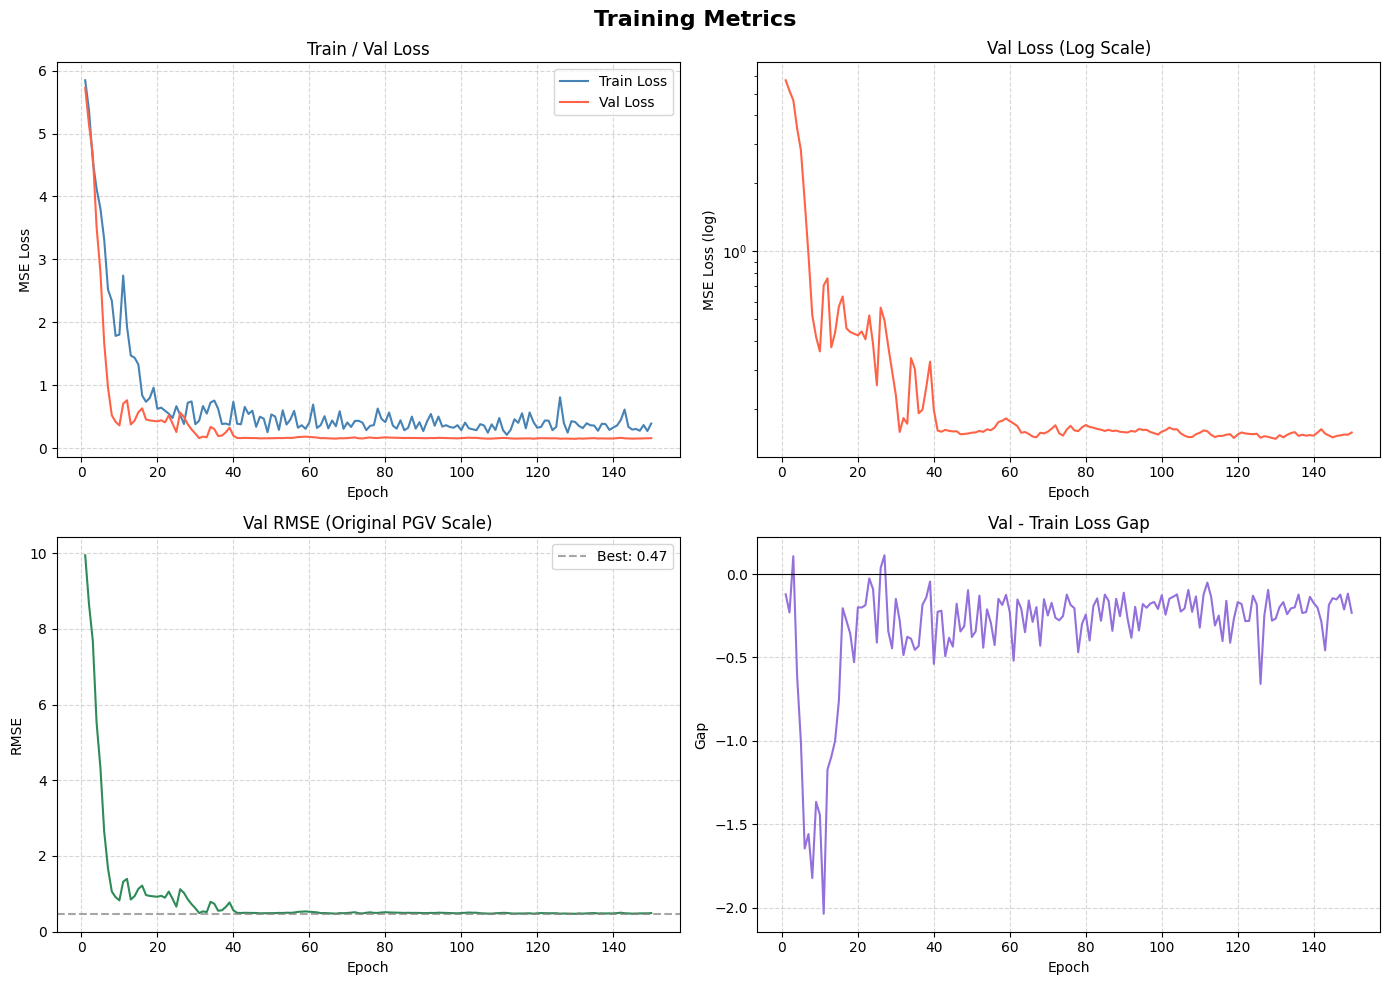


학습 결과 요약
  Best Val Loss    : 0.1481  (Epoch 130)
  Best Val RMSE    : 0.47
  Val Loss 스파이크 : 0회 (Val Loss > 10 기준)
  최종 Train Loss  : 0.3903
  최종 Val Loss    : 0.1579


In [ ]:
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    full_dataset = Dataset(pgv_path, seismic_path, gnss_path, is_train=False)

    # pgv_dict 키 확인
    print("pgv_dict 키 샘플:", list(full_dataset.pgv_dict.keys())[:5])

    # seismic_station 확인
    print("seismic_station 샘플:", [str(full_dataset.seismic_station[i]).strip() for i in range(5)])

    # 매칭 여부 확인
    for i in range(5):
      station = str(full_dataset.seismic_station[i]).strip().strip("[]'\"")
      pgv = full_dataset.pgv_dict.get(station, "매칭 안 됨")
      print(f"{station} → {pgv}")


    total_size = len(full_dataset)
    train_size = int(total_size * 0.8)
    val_size = total_size - train_size

    train_subset = Subset(full_dataset, list(range(0, train_size)))
    val_subset = Subset(full_dataset, list(range(train_size, total_size)))

    # Train dataset에만 is_train=True를 강제 적용
    train_subset.dataset.is_train = True
    val_subset.dataset.is_train = False

    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

    model = MultimodalModel().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

    # 지정된 에폭(20, 40, 60, 90)을 통과할 때마다 학습률에 gamma(0.1)를 곱해 감소
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[40, 80, 110], gamma=0.1)

    best_val_loss = float('inf')
    best_model_weights = None

    # Metrics to store for plotting
    metrics = {
        'epoch': [],
        'train_loss': [],
        'val_loss': [],
        'val_rmse': []
    }

    print("=========================== Train ==========================")

    for epoch in range(NUM_EPOCHS):
        # Train
        model.train()
        train_loss = 0.0

        for x_seismic, x_gnss, targets in train_loader:
            x_seismic, x_gnss, targets = x_seismic.to(device), x_gnss.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(x_seismic, x_gnss)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_seismic, x_gnss, targets in val_loader:
                x_seismic, x_gnss, targets = x_seismic.to(device), x_gnss.to(device), targets.to(device)
                outputs = model(x_seismic, x_gnss)
                loss = criterion(outputs, targets)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        # 1에폭이 끝날 때마다 스케줄러 업데이트
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # 로그 스케일링된 MSE에서 원래 PGV 스케일의 RMSE로 복원하여 출력
        val_rmse_original_scale = np.expm1(avg_val_loss ** 0.5)

        # Store metrics
        metrics['epoch'].append(epoch + 1)
        metrics['train_loss'].append(avg_train_loss)
        metrics['val_loss'].append(avg_val_loss)
        metrics['val_rmse'].append(val_rmse_original_scale)

        # 최고 성능 갱신 시 모델 자동 저장
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_weights = copy.deepcopy(model.state_dict())

        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] LR: {current_lr:.8f} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} (Original PGV RMSE: {val_rmse_original_scale:.2f})")

    # 최고 성능 모델 파일로 추출
    torch.save(best_model_weights, 'best_seismic_model.pth')

    # 메모리 상의 모델도 최고 성능 모델로 저장
    model.load_state_dict(best_model_weights)
    return model, metrics # Return model and metrics

if __name__ == '__main__':
    import matplotlib.pyplot as plt

    best_model, metric = main()

    # 학습 지표 시각화
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Training Metrics', fontsize=16, fontweight='bold')

    epochs = metric['epoch']

    # 1. Train / Val Loss
    ax = axes[0, 0]
    ax.plot(epochs, metric['train_loss'], label='Train Loss', color='steelblue')
    ax.plot(epochs, metric['val_loss'],   label='Val Loss',   color='tomato')
    ax.set_title('Train / Val Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

    # 2. Val Loss 스파이크 확인 (로그 스케일)
    ax = axes[0, 1]
    ax.plot(epochs, metric['val_loss'], color='tomato')
    ax.set_yscale('log')
    ax.set_title('Val Loss (Log Scale)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss (log)')
    ax.grid(True, linestyle='--', alpha=0.5)

    # 3. Val RMSE (Original PGV Scale)
    ax = axes[1, 0]
    ax.plot(epochs, metric['val_rmse'], color='seagreen')
    ax.axhline(y=min(metric['val_rmse']), color='gray',
               linestyle='--', alpha=0.7,
               label=f"Best: {min(metric['val_rmse']):.2f}")
    ax.set_title('Val RMSE (Original PGV Scale)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('RMSE')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

    # 4. Train / Val Loss 갭 (과적합 확인)
    ax = axes[1, 1]
    gap = [v - t for v, t in zip(metric['val_loss'], metric['train_loss'])]
    ax.plot(epochs, gap, color='mediumpurple')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.set_title('Val - Train Loss Gap')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Gap')
    ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # 결과 요약 출력
    best_epoch = metric['val_loss'].index(min(metric['val_loss'])) + 1
    print(f"\n학습 결과 요약")
    print(f"  Best Val Loss    : {min(metric['val_loss']):.4f}  (Epoch {best_epoch})")
    print(f"  Best Val RMSE    : {min(metric['val_rmse']):.2f}")
    print(f"  Val Loss 스파이크 : {sum(1 for v in metric['val_loss'] if v > 10)}회 (Val Loss > 10 기준)")
    print(f"  최종 Train Loss  : {metric['train_loss'][-1]:.4f}")
    print(f"  최종 Val Loss    : {metric['val_loss'][-1]:.4f}")

### Best model 결과 시각화

총 샘플 수: 35
actuals 범위: 1.6949 ~ 3.9719
predictions 범위: 2.0072 ~ 3.7267
actuals 원래 스케일: 4.4461 ~ 52.0828


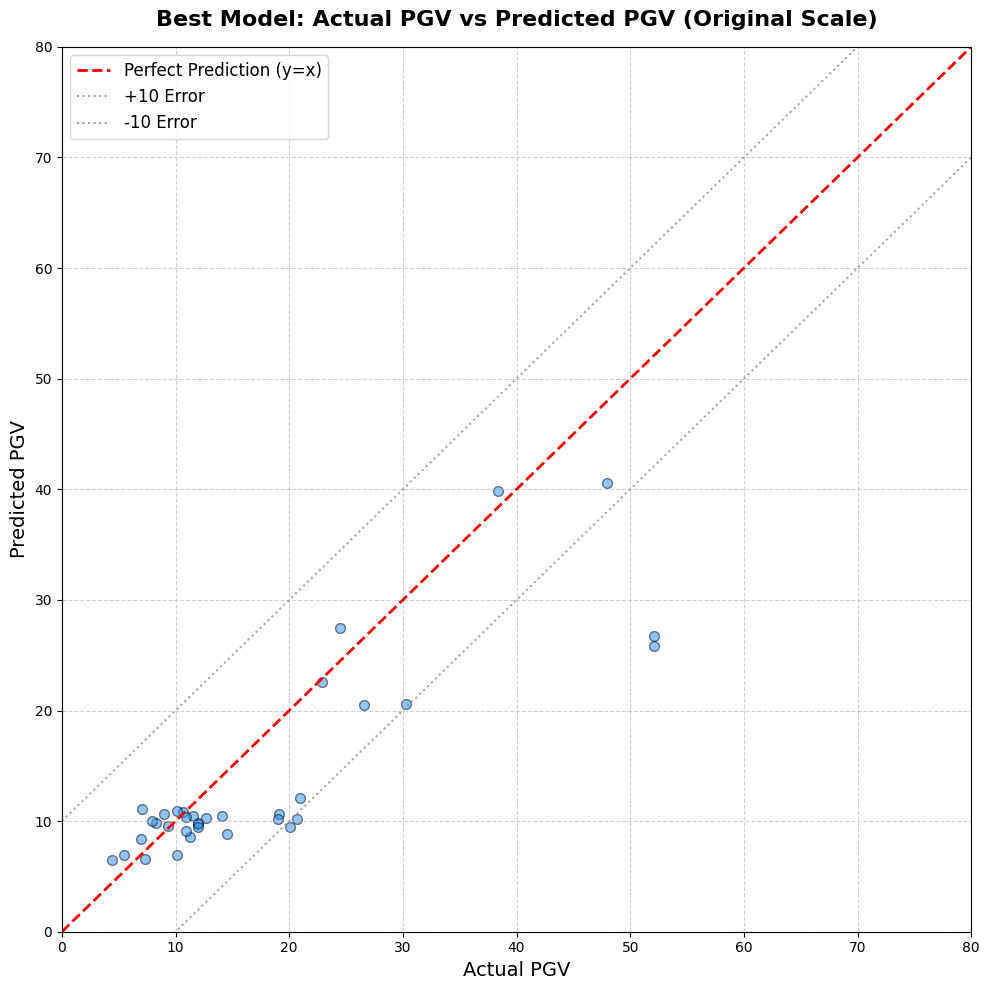

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split

full_dataset = Dataset(pgv_path, seismic_path, gnss_path, is_train=False)

total_size = len(full_dataset)
train_size = int(total_size * 0.8)
val_size = total_size - train_size

torch.manual_seed(42)
_, val_subset = random_split(full_dataset, [train_size, val_size])

val_subset.dataset.is_train = False
val_loader = DataLoader(val_subset, batch_size=8, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model = MultimodalModel().to(device)
best_model.load_state_dict(torch.load('best_seismic_model.pth'))

def plot_best_model_predictions(model, val_loader, device):
    model.eval()

    actuals = []
    predictions = []

    with torch.no_grad():
        for x_seismic, x_gnss, targets in val_loader:
            x_seismic = x_seismic.to(device)
            x_gnss = x_gnss.to(device)
            outputs = model(x_seismic, x_gnss)

            actuals.extend(targets.cpu().numpy().flatten())
            predictions.extend(outputs.cpu().numpy().flatten())

    print(f"총 샘플 수: {len(actuals)}")
    print(f"actuals 범위: {min(actuals):.4f} ~ {max(actuals):.4f}")
    print(f"predictions 범위: {min(predictions):.4f} ~ {max(predictions):.4f}")
    print(f"actuals 원래 스케일: {np.expm1(min(actuals)):.4f} ~ {np.expm1(max(actuals)):.4f}")

    # Log -> Original Scale
    actuals_original = np.expm1(np.array(actuals))
    predictions_original = np.expm1(np.array(predictions))

    # 그래프
    plt.figure(figsize=(10, 10))
    plt.scatter(actuals_original, predictions_original, alpha=0.5, color='dodgerblue', edgecolor='k', s=50)

    max_val = 80
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')
    plt.plot([0, max_val], [10, max_val + 10], color='gray', linestyle=':', alpha=0.7, label='+10 Error')
    plt.plot([0, max_val], [-10, max_val - 10], color='gray', linestyle=':', alpha=0.7, label='-10 Error')

    plt.title('Best Model: Actual PGV vs Predicted PGV (Original Scale)', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Actual PGV', fontsize=14)
    plt.ylabel('Predicted PGV', fontsize=14)

    plt.xlim(0, max_val)
    plt.ylim(0, max_val)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

plot_best_model_predictions(best_model, val_loader, device)